<a href="https://www.kaggle.com/code/sonawanelalitsunil/ai-digital-media-evolution-2020-25-ml-37-5?scriptVersionId=231908553" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/impact-of-ai-on-digital-media-2020-2025/Global_AI_Content_Impact_Dataset.csv


## 🧠 AI & Digital Media Evolution (2020–2025)

#### AI has revolutionized digital media by automating content creation, enhancing personalization, transforming advertising strategies, and reshaping user engagement. From AI-generated art to tailored news feeds, the landscape between 2020–2025 has shifted toward smarter, data-driven experiences.



### Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/impact-of-ai-on-digital-media-2020-2025/Global_AI_Content_Impact_Dataset.csv')

In [3]:
df.head()

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
0,South Korea,2022,Media,44.29,33.09,16.77,46.12,74.79,Bard,Strict,40.77,18.73
1,China,2025,Legal,34.75,66.74,46.89,52.46,26.17,DALL-E,Strict,35.67,35.02
2,USA,2022,Automotive,81.06,96.13,10.66,45.60,39.66,Stable Diffusion,Moderate,54.47,22.76
3,France,2021,Legal,85.24,93.76,27.70,78.24,29.45,Claude,Moderate,51.84,1.93
4,France,2021,Gaming,78.95,45.62,17.45,1.05,21.70,Midjourney,Strict,41.77,21.41


In [4]:
df.tail()

,Country,Year,Industry,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Top AI Tools Used,Regulation Status,Consumer Trust in AI (%),Market Share of AI Companies (%)
195,Germany,2021,Automotive,89.44,52.98,48.47,12.14,30.60,DALL-E,Lenient,77.21,44.35
196,Germany,2020,Media,70.11,28.26,27.62,57.86,58.71,DALL-E,Strict,78.74,31.73
197,France,2023,Marketing,65.77,49.83,39.94,79.44,43.73,Synthesia,Lenient,81.58,14.62
198,Australia,2023,Automotive,45.35,20.49,33.21,50.50,41.73,Claude,Strict,47.42,43.11
199,South Korea,2020,Healthcare,10.53,20.97,23.64,34.27,45.67,Stable Diffusion,Moderate,58.52,33.37


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Country                                     200 non-null    object 
 1   Year                                        200 non-null    int64  
 2   Industry                                    200 non-null    object 
 3   AI Adoption Rate (%)                        200 non-null    float64
 4   AI-Generated Content Volume (TBs per year)  200 non-null    float64
 5   Job Loss Due to AI (%)                      200 non-null    float64
 6   Revenue Increase Due to AI (%)              200 non-null    float64
 7   Human-AI Collaboration Rate (%)             200 non-null    float64
 8   Top AI Tools Used                           200 non-null    object 
 9   Regulation Status                           200 non-null    object 
 10  Consumer Trust

In [6]:
df.describe()

,Year,AI Adoption Rate (%),AI-Generated Content Volume (TBs per year),Job Loss Due to AI (%),Revenue Increase Due to AI (%),Human-AI Collaboration Rate (%),Consumer Trust in AI (%),Market Share of AI Companies (%)
count,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2022.315000,54.265850,46.07260,25.788250,39.719450,54.102150,59.425150,26.569550
std,1.825496,24.218067,29.16122,13.901105,23.829545,19.247079,17.319668,14.023729
min,2020.000000,10.530000,1.04000,0.090000,0.140000,20.210000,30.120000,1.180000
25%,2021.000000,33.222500,20.32250,14.995000,17.907500,37.770000,44.755000,14.052500
50%,2022.000000,53.310000,44.32000,25.735000,42.100000,54.515000,59.215000,27.390000
75%,2024.000000,76.220000,71.62000,37.417500,58.697500,69.402500,74.885000,38.432500
max,2025.000000,94.760000,99.06000,49.710000,79.550000,88.290000,89.880000,49.280000


In [7]:
df.shape

(200, 12)

In [8]:
df.duplicated().sum()

0

In [9]:
df.isnull().sum()

Country                                       0
Year                                          0
Industry                                      0
AI Adoption Rate (%)                          0
AI-Generated Content Volume (TBs per year)    0
Job Loss Due to AI (%)                        0
Revenue Increase Due to AI (%)                0
Human-AI Collaboration Rate (%)               0
Top AI Tools Used                             0
Regulation Status                             0
Consumer Trust in AI (%)                      0
Market Share of AI Companies (%)              0
dtype: int64

In [10]:
df.dtypes

Country                                        object
Year                                            int64
Industry                                       object
AI Adoption Rate (%)                          float64
AI-Generated Content Volume (TBs per year)    float64
Job Loss Due to AI (%)                        float64
Revenue Increase Due to AI (%)                float64
Human-AI Collaboration Rate (%)               float64
Top AI Tools Used                              object
Regulation Status                              object
Consumer Trust in AI (%)                      float64
Market Share of AI Companies (%)              float64
dtype: object

In [11]:
df.columns

Index(['Country', 'Year', 'Industry', 'AI Adoption Rate (%)',
       'AI-Generated Content Volume (TBs per year)', 'Job Loss Due to AI (%)',
       'Revenue Increase Due to AI (%)', 'Human-AI Collaboration Rate (%)',
       'Top AI Tools Used', 'Regulation Status', 'Consumer Trust in AI (%)',
       'Market Share of AI Companies (%)'],
      dtype='object')

## Data visualizations

In [12]:
import plotly.express as px

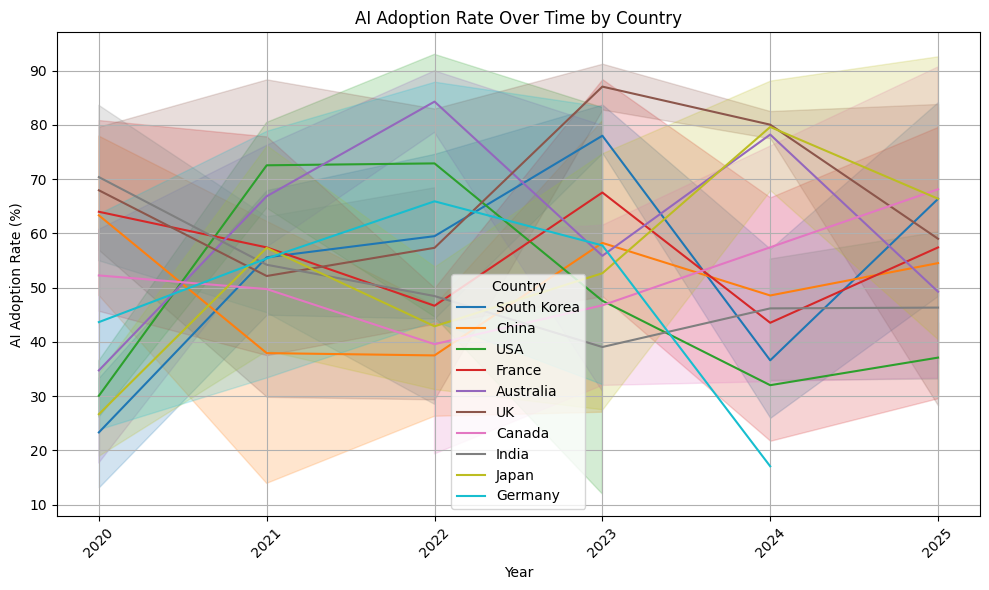

In [13]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='AI Adoption Rate (%)', hue='Country')
plt.title('AI Adoption Rate Over Time by Country')
plt.ylabel('AI Adoption Rate (%)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
latest_year = df['Year'].max()
latest_df = df[df['Year'] == latest_year]

fig = px.choropleth(latest_df,
                    locations='Country',
                    locationmode='country names',
                    color='AI Adoption Rate (%)',
                    title=f'AI Adoption Rate by Country in {latest_year}',
                    color_continuous_scale='Blues')
fig.show()


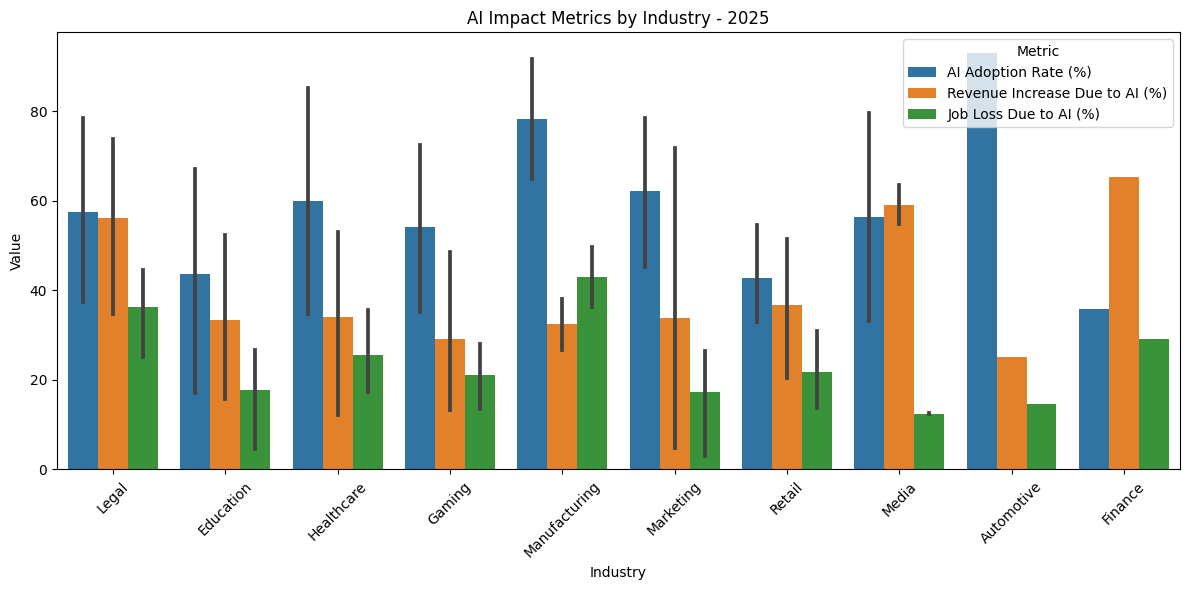

In [15]:
industry_df = df[df['Year'] == latest_year]

impact_cols = ['AI Adoption Rate (%)', 'Revenue Increase Due to AI (%)', 'Job Loss Due to AI (%)']
industry_df = industry_df[['Industry'] + impact_cols].dropna()

industry_melted = pd.melt(industry_df, id_vars='Industry', var_name='Metric', value_name='Value')

plt.figure(figsize=(12, 6))
sns.barplot(data=industry_melted, x='Industry', y='Value', hue='Metric')
plt.xticks(rotation=45)
plt.title(f'AI Impact Metrics by Industry - {latest_year}')
plt.tight_layout()
plt.show()


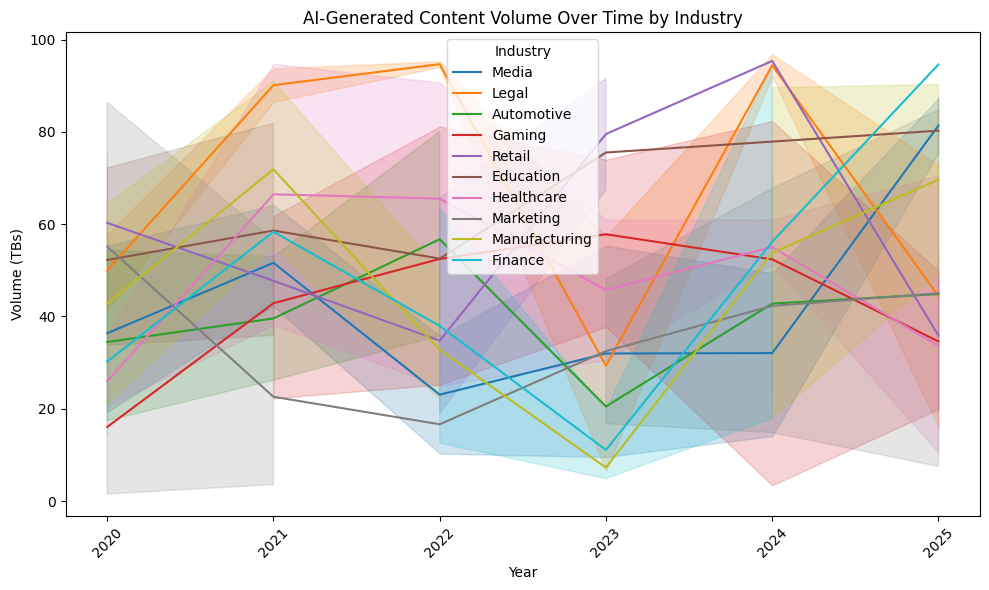

In [16]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='AI-Generated Content Volume (TBs per year)', hue='Industry')
plt.title('AI-Generated Content Volume Over Time by Industry')
plt.ylabel('Volume (TBs)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


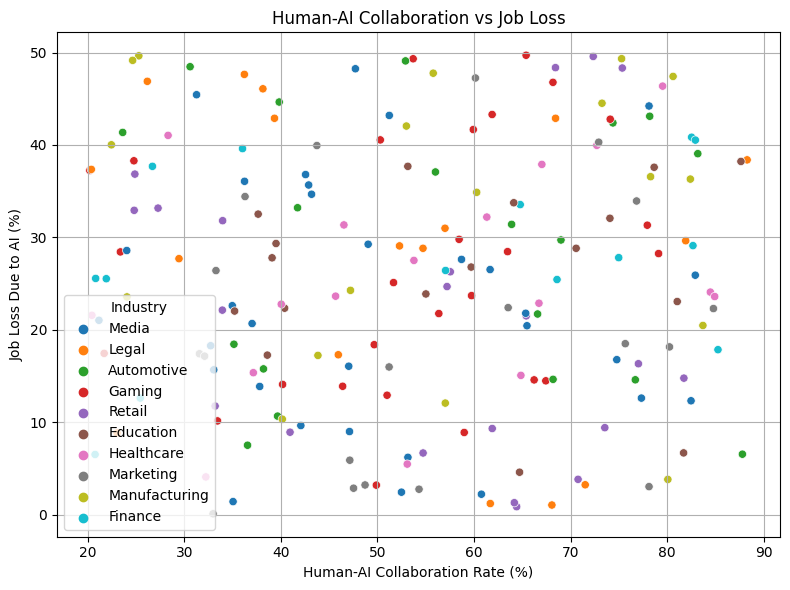

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Human-AI Collaboration Rate (%)', y='Job Loss Due to AI (%)', hue='Industry')
plt.title('Human-AI Collaboration vs Job Loss')
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
fig = px.scatter(df[df['Year'] == latest_year], 
                 x='AI Adoption Rate (%)', 
                 y='Revenue Increase Due to AI (%)',
                 size='Market Share of AI Companies (%)',
                 color='Industry',
                 hover_name='Country',
                 title='AI Adoption vs Revenue Increase (Bubble Chart)')
fig.show()


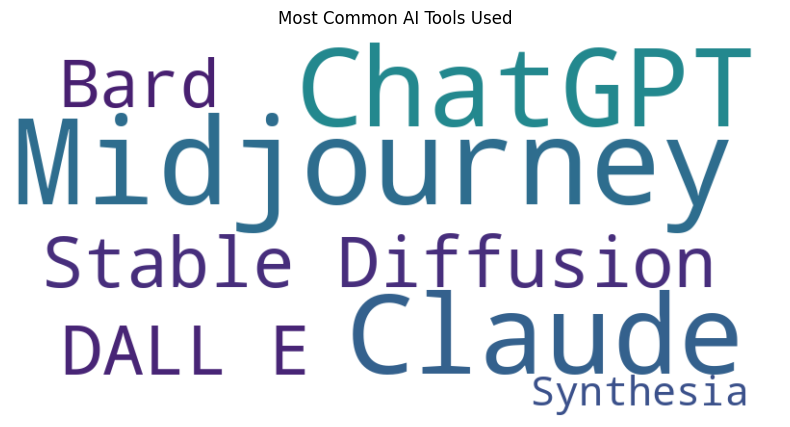

In [19]:
from wordcloud import WordCloud

tools_text = ' '.join(df['Top AI Tools Used'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(tools_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common AI Tools Used')
plt.show()


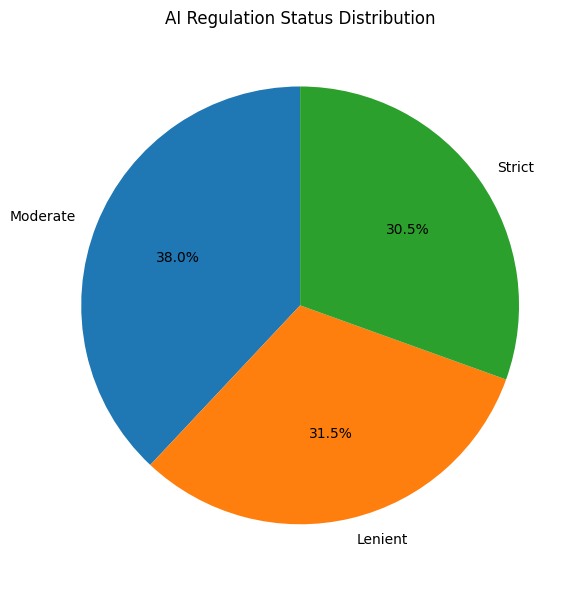

In [20]:
plt.figure(figsize=(6, 6))
df['Regulation Status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('AI Regulation Status Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()


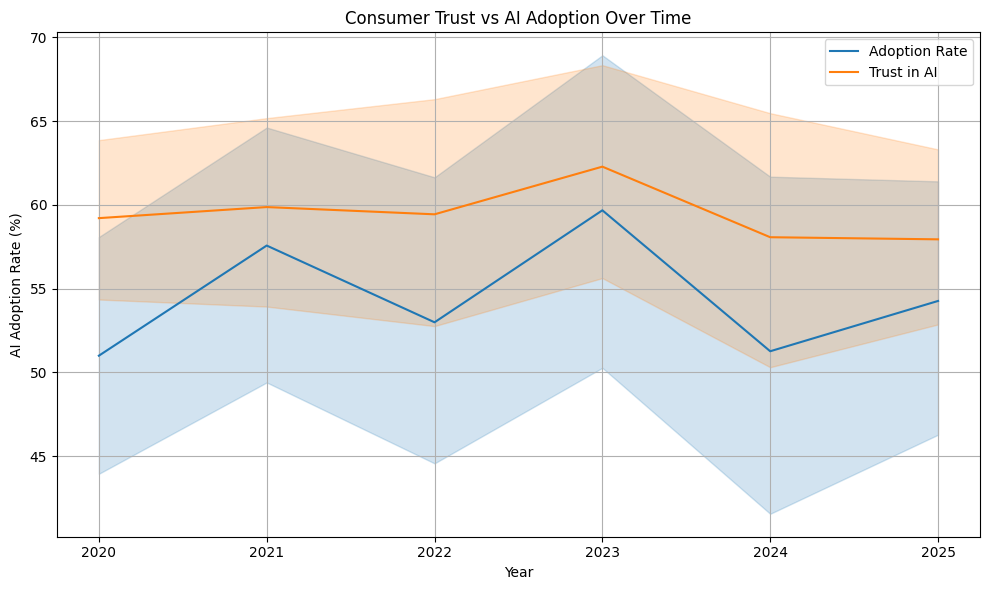

In [21]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Year', y='AI Adoption Rate (%)', label='Adoption Rate')
sns.lineplot(data=df, x='Year', y='Consumer Trust in AI (%)', label='Trust in AI')
plt.title('Consumer Trust vs AI Adoption Over Time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


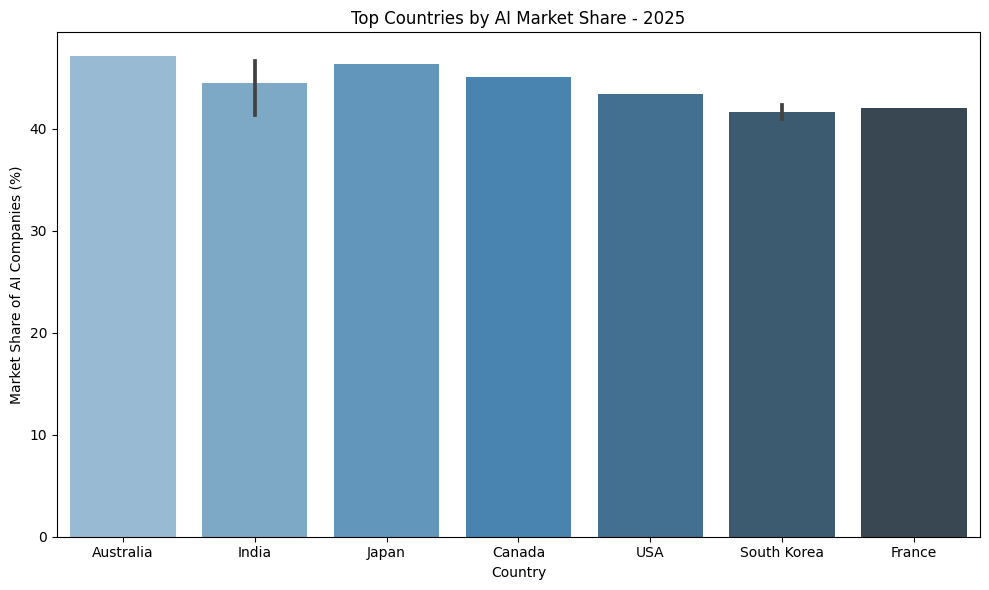

In [22]:
top_market_df = df[df['Year'] == latest_year].sort_values(by='Market Share of AI Companies (%)', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_market_df, x='Country', y='Market Share of AI Companies (%)', palette='Blues_d')
plt.title(f'Top Countries by AI Market Share - {latest_year}')
plt.tight_layout()
plt.show()


## Predictive modeling

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [24]:
# Drop rows with missing values (or use imputation)
df.dropna(inplace=True)

In [25]:
label_encoders = {}
categorical_cols = ['Country', 'Industry', 'Top AI Tools Used', 'Regulation Status']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


In [26]:
X = df.drop('Regulation Status', axis=1)
y = df['Regulation Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



📌 Logistic Regression
✅ Accuracy: 32.50%


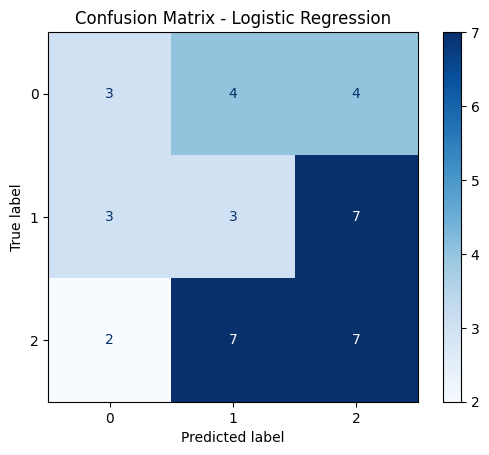


📌 Decision Tree
✅ Accuracy: 17.50%


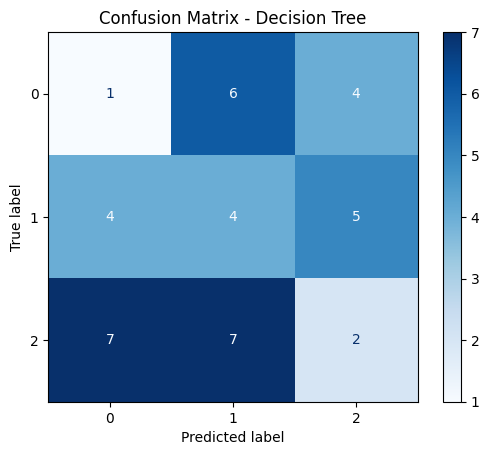


📌 Random Forest
✅ Accuracy: 40.00%


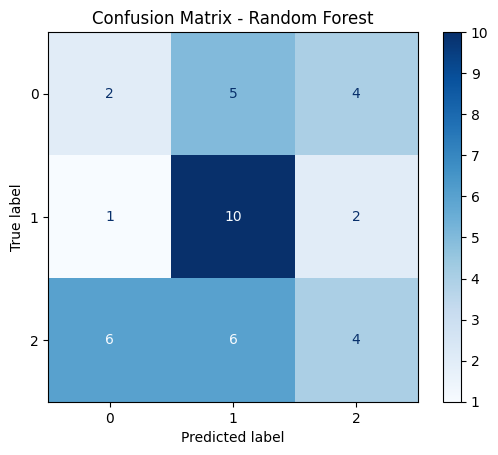


📌 SVM
✅ Accuracy: 32.50%


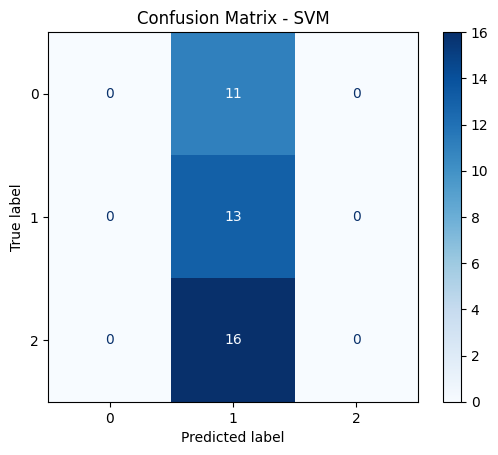


📌 Naive Bayes
✅ Accuracy: 37.50%


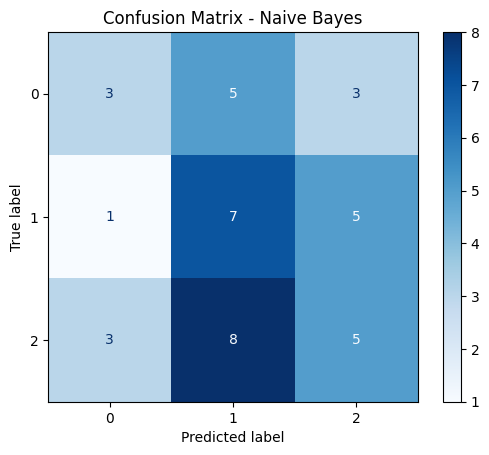


📌 KNN
✅ Accuracy: 27.50%


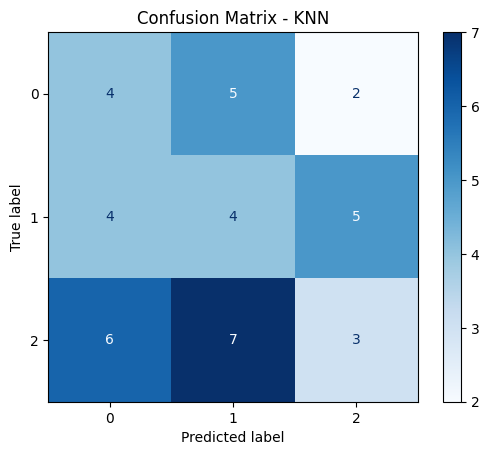

In [27]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    
    print(f"\n📌 {name}")
    print(f"✅ Accuracy: {acc:.2f}%")
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()


In [28]:
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy (%)'])
results_df = results_df.sort_values(by='Accuracy (%)', ascending=False)

print("\n📊 Model Accuracy Comparison:")
print(results_df)



📊 Model Accuracy Comparison:
                     Accuracy (%)
Random Forest                40.0
Naive Bayes                  37.5
Logistic Regression          32.5
SVM                          32.5
KNN                          27.5
Decision Tree                17.5


## Thank you...pls upvote